# Análisis exploratorio: edad, participación, datos de la misma semana y contexto del partido

## Qué responde este notebook

[`2.1_eda_targets.ipynb`](2.1_eda_targets.ipynb) mostró los tres resultados y
[`2.2_eda_perfil_variables.ipynb`](2.2_eda_perfil_variables.ipynb), cada variable por sí sola. Aquí
se empiezan a cruzar variables con los resultados, en las semanas con al menos un pase dirigido de
2024-2025, para responder cuatro preguntas:

1. ¿La edad y la experiencia de un receptor se relacionan con su producción?
2. `air_yards_share` y `wopr` a veces salen negativos o mayores a 1: ¿es un error?
3. ¿Cuánto infla una correlación usar datos de la misma semana que se quiere predecir?
4. ¿El contexto del partido (líneas de apuestas, clima) se relaciona con la producción de un
   receptor?

Las variables se definen en el [glosario](../../../docs/data/GLOSARIO_VARIABLES.md).

In [1]:
import sys
sys.path.insert(0, "../src")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import data, features

sns.set_style("whitegrid")
AZUL, NARANJA, VERDE, GRIS, GRIS_CLARO = "#2a78d6", "#eb6834", "#1baf7a", "#888780", "#c3c2b7"

SEASONS = [2024, 2025]
stats = data.cargar_stats_semanales(SEASONS)
wr_activo = stats[(stats["position"] == "WR") & (stats["targets"] > 0)].copy()
jugadores = data.cargar_jugadores()
print("filas WR activas (targets > 0):", wr_activo.shape[0])

filas WR activas (targets > 0): 4187


## 1. Edad y experiencia

La edad se calcula al 1 de septiembre de cada temporada (cerca del inicio de la temporada regular) y
los años de experiencia como `temporada − temporada de novato`.

In [2]:
wr_j = wr_activo.merge(
    jugadores[["gsis_id", "birth_date", "rookie_season"]],
    left_on="player_id", right_on="gsis_id", how="left"
)
ref = pd.to_datetime(wr_j["season"].astype(str) + "-09-01")
wr_j["edad"] = (ref - wr_j["birth_date"]).dt.days / 365.25
wr_j["anios_experiencia"] = wr_j["season"] - wr_j["rookie_season"]

print("cobertura de birth_date/rookie_season:", wr_j["birth_date"].notna().mean(), "/", wr_j["rookie_season"].notna().mean())
print(wr_j["edad"].describe()[["mean", "min", "max"]])
print()
print("correlacion (lineal) edad vs yardas:", round(wr_j["edad"].corr(wr_j["receiving_yards"]), 3))
print("correlacion (lineal) experiencia vs yardas:", round(wr_j["anios_experiencia"].corr(wr_j["receiving_yards"]), 3))

cobertura de birth_date/rookie_season: 1.0 / 1.0
mean    26.186978
min     21.097878
max     35.028063
Name: edad, dtype: float64

correlacion (lineal) edad vs yardas: -0.053
correlacion (lineal) experiencia vs yardas: 0.011


Las dos correlaciones lineales salen prácticamente en cero (−0.053 y 0.011). Antes de concluir que
la experiencia no importa conviene mirar la relación por grupos, porque una correlación lineal solo
detecta relaciones en línea recta.

            receptions  receiving_yards  receiving_tds
exp_bucket                                            
Rookie        2.359690        29.750388       0.204651
1-2 años      2.992107        37.844515       0.243883
3-5 años      3.408938        44.365093       0.279089
6+ años       2.863177        34.139578       0.215794


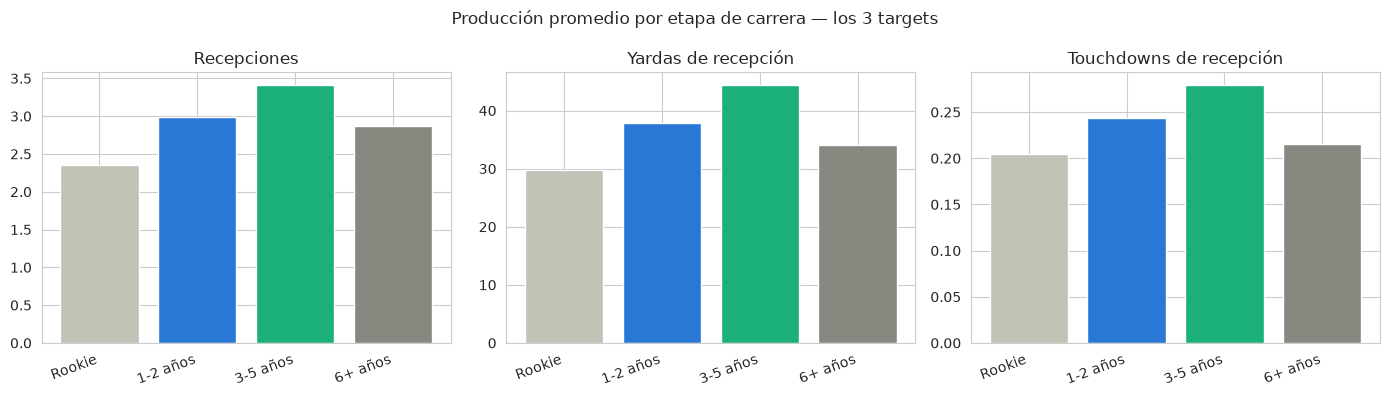

In [3]:
bins = [-1, 0, 2, 5, 100]
labels = ["Rookie", "1-2 años", "3-5 años", "6+ años"]
wr_j["exp_bucket"] = pd.cut(wr_j["anios_experiencia"], bins=bins, labels=labels)
resumen_exp = wr_j.groupby("exp_bucket", observed=True)[["receptions", "receiving_yards", "receiving_tds"]].mean()
print(resumen_exp)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colores = [GRIS_CLARO, AZUL, VERDE, GRIS]
for ax, col, titulo in zip(axes, ["receptions", "receiving_yards", "receiving_tds"],
                            ["Recepciones", "Yardas de recepción", "Touchdowns de recepción"]):
    ax.bar(resumen_exp.index.astype(str), resumen_exp[col], color=colores)
    ax.set_title(titulo)
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
plt.suptitle("Producción promedio por etapa de carrera — los 3 targets")
plt.tight_layout()
plt.show()

**Lectura.** Los tres resultados suben de novato a 3-5 años de experiencia y bajan después:
recepciones 2.36 → 2.99 → **3.41** → 2.86, yardas 29.8 → 37.8 → **44.4** → 34.1 y touchdowns 0.20 →
0.24 → **0.28** → 0.22. Una correlación lineal esconde esa forma de curva en los tres. Es una
comparación entre receptores distintos en cada grupo, no la trayectoria de un mismo jugador: el
grupo de 6 o más años solo incluye a quienes siguen en la liga.

La revisión sistemática de esta y otras variables está en
[`2.5_eda_multivariable.ipynb`](2.5_eda_multivariable.ipynb).

## 2. `air_yards_share` y `wopr` negativos o mayores a 1: ¿error o algo real?

Las dos son participaciones del receptor en el juego aéreo de su equipo, así que se esperaría que
estuvieran entre 0 y 1. El mínimo y el máximo se salen de ese rango; se revisa el caso más extremo
antes de decidir si son datos rotos.

In [4]:
print(wr_activo[["target_share", "air_yards_share", "wopr"]].describe().loc[["min", "max"]])

     target_share  air_yards_share      wopr
min      0.017544        -0.423077 -0.100502
max      0.666667         1.315789  1.518851


La fila con el `air_yards_share` más negativo:

In [5]:
caso = wr_activo.nsmallest(1, "air_yards_share").iloc[0]
print(caso[["player_display_name", "season", "week", "team", "receiving_air_yards", "air_yards_share"]])

equipo_semana = stats[
    (stats["team"] == caso["team"]) & (stats["season"] == caso["season"]) & (stats["week"] == caso["week"])
]
total_equipo = equipo_semana["receiving_air_yards"].sum()
print()
print(f"total de yardas aereas de TODO el equipo esa semana: {total_equipo}")
print(f"{caso['player_display_name']}: {caso['receiving_air_yards']} / {total_equipo} = "
      f"{caso['receiving_air_yards'] / total_equipo:.3f}")

player_display_name    Marvin Mims Jr.
season                            2025
week                                18
team                               DEN
receiving_air_yards                -11
air_yards_share              -0.423077
Name: 36306, dtype: object

total de yardas aereas de TODO el equipo esa semana: 26
Marvin Mims Jr.: -11 / 26 = -0.423


**No es un error.** Esa semana el equipo sumó solo 26 yardas aéreas y Marvin Mims Jr. tuvo −11: pases
atrapados detrás de la línea de golpeo. Dividir un valor individual entre un total tan pequeño da una
«participación» fuera de [0, 1] sin que nada esté mal calculado. Es aritmética correcta sobre un
denominador inusual, no un dato corrupto como los del archivo de ADP de
[`1.1_calidad_fuentes.ipynb`](1.1_calidad_fuentes.ipynb). Se usa la columna tal cual.

## 3. Cuánto infla una correlación usar datos de la misma semana

`target_share` de la semana que se predice ya contiene parte del resultado: si esa semana le lanzaron
muchos pases al receptor, probablemente tuvo muchas yardas. Un modelo no puede usarla, porque no se
conoce antes del partido. Se compara su correlación con las yardas contra la de
`target_share_season_avg`, el promedio de las semanas anteriores de la misma temporada, que sí se
conoce antes ([`1.4_promedios_sin_fuga.ipynb`](1.4_promedios_sin_fuga.ipynb)). Las dos se miden sobre
las mismas filas: las que tienen al menos una semana anterior en la temporada.

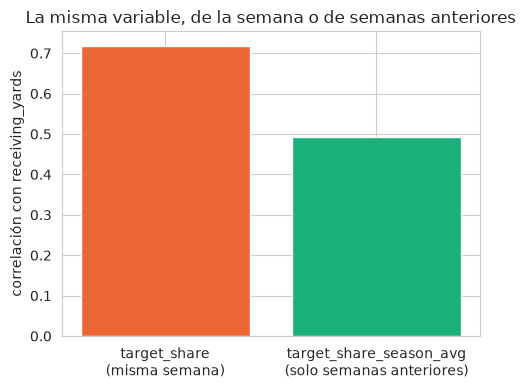

filas con promedio de semanas anteriores disponible: 3741
target_share de la misma semana: 0.718
target_share_season_avg (semanas anteriores): 0.492


In [6]:
con_features = features.agregar_promedios_jugador(wr_activo, ["target_share"], id_col="player_id")
filas = con_features.dropna(subset=["target_share_season_avg"])
corr_misma_semana = filas["target_share"].corr(filas["receiving_yards"])
corr_rezagada = filas["target_share_season_avg"].corr(filas["receiving_yards"])

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(
    ["target_share\n(misma semana)", "target_share_season_avg\n(solo semanas anteriores)"],
    [corr_misma_semana, corr_rezagada],
    color=[NARANJA, VERDE],
)
ax.set_ylabel("correlación con receiving_yards")
ax.set_title("La misma variable, de la semana o de semanas anteriores")
plt.tight_layout()
plt.show()

print(f"filas con promedio de semanas anteriores disponible: {len(filas)}")
print(f"target_share de la misma semana: {corr_misma_semana:.3f}")
print(f"target_share_season_avg (semanas anteriores): {corr_rezagada:.3f}")

Con la misma variable y las mismas 3,741 filas, la correlación baja de 0.718 (misma semana) a 0.492
(semanas anteriores). La diferencia es lo que infla usar información que no se tiene antes del
partido; 0.49 es la relación que un modelo sí puede aprovechar, y es la versión rezagada la que
construye `features.py`.

## 4. ¿El contexto del partido se relaciona con la producción de un receptor?

Se construye el total implícito de cada equipo: los puntos que las casas de apuestas esperan que
anote, a partir de la línea (`spread_line`, positiva cuando el local es favorito) y el total del
partido (`total_line`); ver el [glosario](../../../docs/data/GLOSARIO_VARIABLES.md), sección 2. Para
el local es `(total + spread) / 2` y para el visitante `(total − spread) / 2`. Antes de usarlo se
verifica que siga a los puntos que el equipo de verdad anotó. También se revisan la temperatura y el
viento.

total implicito contra los puntos que de verdad anoto el equipo: correlacion 0.428


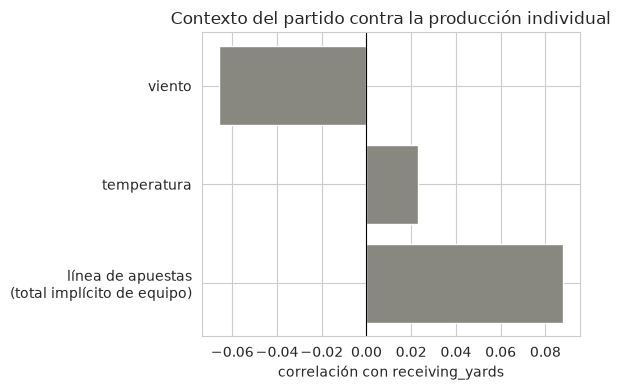

línea de apuestas (total implícito de equipo): 0.0878
temperatura: 0.0229
viento: -0.0660


In [7]:
calendario = data.cargar_calendario(SEASONS)
columnas = ["season", "week", "spread_line", "total_line", "temp", "wind"]
cal_home = calendario[columnas + ["home_team", "home_score"]].rename(columns={"home_team": "team", "home_score": "puntos"})
cal_away = calendario[columnas + ["away_team", "away_score"]].rename(columns={"away_team": "team", "away_score": "puntos"})
# spread_line positivo = el local es favorito por esa cantidad de puntos
cal_home["team_implied_total"] = (cal_home["total_line"] + cal_home["spread_line"]) / 2
cal_away["team_implied_total"] = (cal_away["total_line"] - cal_away["spread_line"]) / 2
cal_long = pd.concat([cal_home, cal_away], ignore_index=True)
print(f"total implicito contra los puntos que de verdad anoto el equipo: correlacion "
      f"{cal_long['team_implied_total'].corr(cal_long['puntos']):.3f}")

wr_vegas = wr_activo.merge(cal_long, on=["season", "week", "team"], how="left")

corrs = {
    "línea de apuestas\n(total implícito de equipo)": wr_vegas["team_implied_total"].corr(wr_vegas["receiving_yards"]),
    "temperatura": wr_vegas["temp"].corr(wr_vegas["receiving_yards"]),
    "viento": wr_vegas["wind"].corr(wr_vegas["receiving_yards"]),
}
fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(list(corrs.keys()), list(corrs.values()), color=GRIS)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("correlación con receiving_yards")
ax.set_title("Contexto del partido contra la producción individual")
plt.tight_layout()
plt.show()

for k, v in corrs.items():
    print(f"{k.replace(chr(10), ' ')}: {v:.4f}")

El total implícito sí sigue a los puntos reales del equipo (correlación de 0.428), así que está bien
construido. Contra las yardas de cada receptor, las tres correlaciones son pequeñas: 0.088 para el
total implícito, 0.023 para la temperatura y −0.066 para el viento. Probablemente, que un equipo
espere anotar más se traduce poco en las yardas de un receptor en particular, porque esa producción
se reparte entre varios jugadores. El total implícito es la mayor de las tres, y una correlación
aislada no dice si aporta algo que las variables de uso no tengan ya: eso se evalúa en la selección
de variables (ver [`docs/HALLAZGOS.md`](../../../docs/HALLAZGOS.md)).

## Cierre

- La experiencia se relaciona con la producción, pero no de forma lineal: sube hasta 3-5 años y baja
  después, en los tres resultados. Una correlación simple no lo detecta; un modelo que capte curvas sí
  puede aprovecharla.
- `air_yards_share` y `wopr` pueden salir negativos o mayores a 1 (Marvin Mims Jr.: −11 de 26 yardas
  aéreas del equipo, −0.42): es aritmética correcta con un total de equipo pequeño, no un error.
- Usar `target_share` de la misma semana infla su correlación con las yardas de 0.49 a 0.72; los
  modelos usan solo la versión de semanas anteriores.
- El total implícito de las líneas de apuestas está bien construido (0.43 con los puntos reales del
  equipo), pero se relaciona poco con las yardas de un receptor (0.088); la temperatura y el viento,
  todavía menos. Si el total implícito aporta algo más allá de las variables de uso se evalúa en la
  selección de variables.

Anterior: [`2.2_eda_perfil_variables.ipynb`](2.2_eda_perfil_variables.ipynb) · Siguiente:
[`2.4_eda_equipos.ipynb`](2.4_eda_equipos.ipynb)